## Orange Cap winners prediction



In [3]:
import pandas as pd

# Load the processed DataFrame from the main file
df_final = pd.read_pickle("../pandas/df_final_processed.pkl")

In [4]:
# last 3 seasons for Recent Form
unique_seasons = sorted(df_final['season'].unique())
recent_seasons = unique_seasons[-3:]
print(f"Analyzing advanced metrics for seasons: {recent_seasons}")

df_recent = df_final[df_final['season'].isin(recent_seasons)].copy()

# Powerplay balls (Overs 0 to 5)
df_recent['is_powerplay'] = df_recent['over'] <= 5

# dot balls and Boundaries
df_recent['is_dot'] = df_recent['batsman_runs'] == 0
df_recent['is_boundary'] = df_recent['batsman_runs'].isin([4, 6])

# dismissals (checking if the batter facing the ball was the one dismissed)
df_recent['is_dismissed'] = (df_recent['is_wicket'] == 1) & (df_recent['player_dismissed'] == df_recent['batter'])

# calculate core aggregates using .agg()
batter_stats = df_recent.groupby('batter').agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count'),
    pp_balls=('is_powerplay', 'sum'),
    dot_balls=('is_dot', 'sum'),
    boundaries=('is_boundary', 'sum'),
    dismissals=('is_dismissed', 'sum'),
    matches_played=('match_id', 'nunique')
).reset_index()

# Filter for players who played at least 15 matches
batter_stats = batter_stats[batter_stats['matches_played'] >= 15].copy()

# Batting Average (Total Runs / Dismissals). Replacing 0 dismissals with 1 to avoid division errors.
batter_stats['batting_avg'] = batter_stats['total_runs'] / batter_stats['dismissals'].replace(0, 1) 

# Strike Rate & Dot Ball Percentage
batter_stats['strike_rate'] = (batter_stats['total_runs'] / batter_stats['balls_faced']) * 100
batter_stats['dot_percent'] = (batter_stats['dot_balls'] / batter_stats['balls_faced']) * 100 

# Powerplay performance (PP Balls / Total Balls)
batter_stats['pp_percent'] = (batter_stats['pp_balls'] / batter_stats['balls_faced']) * 100

# Balls Survived per Match
batter_stats['balls_per_match'] = batter_stats['balls_faced'] / batter_stats['matches_played']

# Calculate Recent Trajectory 
season_runs = df_recent.groupby(['batter', 'season'])['batsman_runs'].sum().unstack(fill_value=0)
season_cols = list(season_runs.columns)

# Trajectory = Most recent season's runs minus the oldest season's runs
season_runs['trajectory'] = season_runs[season_cols[-1]] - season_runs[season_cols[0]]
season_runs = season_runs.reset_index()


# Merge all metrics into one Final Prediction DataFrame
prediction_df = batter_stats.merge(season_runs[['batter', 'trajectory']], on='batter', how='left')


# Orange Cap Composite Score
# Base Score: Average runs per match multiplied by a 14-match season.
prediction_df['base_score'] = (prediction_df['total_runs'] / prediction_df['matches_played']) * 14

# Composite Score Formula:
prediction_df['orange_cap_score'] = (
    prediction_df['base_score'] +                  # Base Projection 
    (prediction_df['batting_avg'] * 1.5) +         # Batting Average 
    (prediction_df['trajectory'] * 0.1) +          # Trajectory bonus
    (prediction_df['pp_percent'] * 0.5)            # Powerplay bonus
)

# Output the Top 5
top_5_advanced = prediction_df.sort_values(by='orange_cap_score', ascending=False).head(5)

display_columns = ['batter', 'base_score', 'batting_avg', 'pp_percent', 'trajectory', 'orange_cap_score']

print("\n---  TOP 5 ORANGE CAP CANDIDATES  ---")
print(top_5_advanced[display_columns].round(2).to_string(index=False))

Analyzing advanced metrics for seasons: ['2022', '2023', '2024']

---  TOP 5 ORANGE CAP CANDIDATES  ---
         batter  base_score  batting_avg  pp_percent  trajectory  orange_cap_score
B Sai Sudharsan      579.04        49.24       32.47         382            707.33
        TM Head      529.20        40.50       63.19         567            678.25
        V Kohli      535.42        45.29       47.88         400            667.30
      DP Conway      588.00        48.63       46.64        -252            659.07
   Shubman Gill      559.69        44.98       46.28         -57            644.59


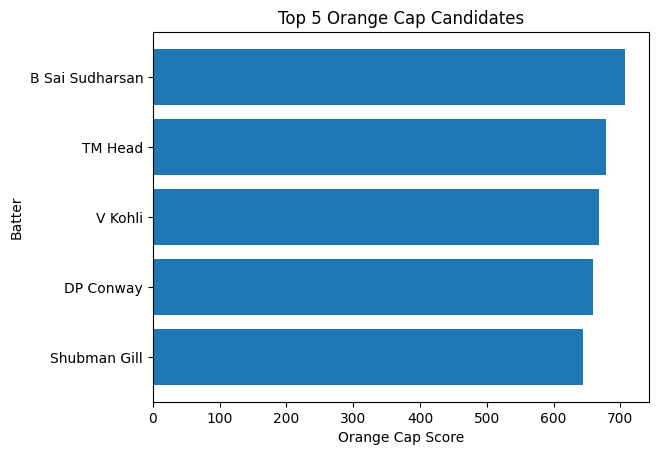

In [6]:
import matplotlib.pyplot as plt

plt.barh(top_5_advanced['batter'], top_5_advanced['orange_cap_score'])
plt.xlabel("Orange Cap Score")
plt.ylabel("Batter")
plt.title("Top 5 Orange Cap Candidates")
plt.gca().invert_yaxis()
plt.show()